# Notebook 1: The Pendulum
### Zero to 6-DOF Rigid Body Dynamics

We start with the simplest possible dynamical system that still has real physics: a pendulum on a rod. By the end of the notebook we will have:

1. Defined a **state vector** and derived equations of motion.
2. Implemented **Euler and RK4** integration and seen why RK4 wins. 
3. Explored **phase portraits** to get a global picture of a dynamical system. 
4. Witnessed **chaos** in the double pendulum. 

Everything here generalizes directly to 6-DOF rigid bodies later in the series. 

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, cm
from matplotlib.colors import Normalize
from IPython.display import HTML
from scipy.integrate import solve_ivp

from plotting import C_BLUE, C_ORANGE, C_GREEN_ACCENT as C_GREEN, C_RED, C_PURPLE, C_DARK, setup_style
from utils import integrate_euler, integrate_rk4

setup_style()
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("Setup complete.")

Setup complete.


---
## 1. The State Vector

**A simulation is just repeatedly computing the next state from the current state.**

For a simple pendulum (rigid body of length $L$, point mass $m$, gravity $g$), the state is fully described by two numbers:

$$\mathbf{x} = \begin{bmatrix} \theta \\ \omega \end{bmatrix}$$

where $\theta$ is the angle from vertical and $\omega = \dot{\theta}$ is the angular velocity.

Newton's second law of rotation gives us $\tau = I\alpha$, where $\tau$ is the net torque (rotational force), $I$ is the moment of interia and $\alpha$ is angular acceleration. 

After substituting with $\tau = -mgL\sin\theta$ and $I = mL^2$, we get:

$$\ddot{\theta} = -\frac{g}{L}\sin\theta$$

We rewrite this single second-order ODE as a system of two first-order ODEs:

$$\frac{d}{dt}\begin{bmatrix} \theta \\ \omega \end{bmatrix} = \begin{bmatrix} \omega \\ -\frac{g}{L}\sin\theta \end{bmatrix}$$

This is the pattern for **every** rigid body simulation: define the state, write down $\dot{\mathbf{x}} = f(\mathbf{x}, t)$, and integrate. 

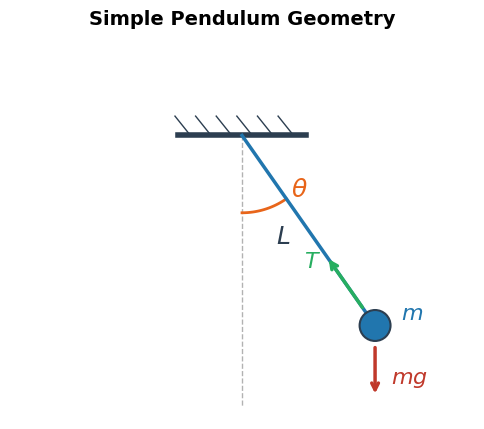

In [2]:
# Pendulum geometry diagram

fig, ax = plt.subplots(1, 1, figsize=(5, 6))
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-2.2, 0.8)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Simple Pendulum Geometry", fontsize=14, fontweight="bold")

# Parameters for the diagram
theta_diag = np.radians(35)
L_diag = 1.8
pivot = np.array([0.0, 0.0])
bob = pivot + L_diag * np.array([np.sin(theta_diag), -np.cos(theta_diag)])

# Pivot mount (ceiling)
ax.plot([-0.5, 0.5], [0.0, 0.0], color=C_DARK, linewidth=4)
for xh in np.linspace(-0.4, 0.4, 6):
    ax.plot([xh, xh - 0.12], [0.0, 0.15], color=C_DARK, linewidth=1)

# Rod
ax.plot([pivot[0], bob[0]], [pivot[1], bob[1]], color=C_BLUE, linewidth=2.5, zorder=3)

# Bob
bob_circle = plt.Circle(bob, 0.12, color=C_BLUE, ec=C_DARK, linewidth=1.5, zorder=4)
ax.add_patch(bob_circle)

# Dashed vertical reference line
ax.plot([0, 0], [0, -L_diag - 0.3], color="gray", linestyle="--", linewidth=1, alpha=0.6)

# Angle arc
arc_angles = np.linspace(-np.pi/2, -np.pi/2 + theta_diag, 40)
arc_r = 0.6
ax.plot(arc_r * np.cos(arc_angles), arc_r * np.sin(arc_angles), color=C_ORANGE, linewidth=2)
# Theta label
mid_angle = -np.pi/2 + theta_diag/2
ax.annotate(
    r'$\theta$', xy=(arc_r * np.cos(mid_angle), arc_r * np.sin(mid_angle)),
    xytext=(arc_r * np.cos(mid_angle) + 0.2, arc_r * np.sin(mid_angle) + 0.1),
    fontsize=18, color=C_ORANGE, fontweight="bold"
)

# Length label
mid_rod = (pivot + bob) / 2
offset = np.array([-0.25, -0.1])
ax.annotate(r'$L$', xy=mid_rod, xytext=mid_rod + offset, fontsize=18, color=C_DARK, fontweight="bold")

# Gravity arrow
ax.annotate(
    '', xy=(bob[0], bob[1] - 0.55), xytext=(bob[0], bob[1] - 0.15),
    arrowprops=dict(arrowstyle='->', color=C_RED, lw=2.5),
)
ax.text(bob[0] + 0.12, bob[1] - 0.45, r'$mg$', fontsize=16, color=C_RED, fontweight="bold")

# Tension arrow (along rod towards pivot)
rod_dir = (pivot - bob) / np.linalg.norm(pivot - bob)
ax.annotate(
    '', xy=bob + rod_dir * 0.65, xytext=bob + rod_dir * 0.15,
    arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=2.5),
)
ax.text(bob[0] - 0.55, bob[1] + 0.45, r'$T$', fontsize=16, color=C_GREEN, fontweight="bold")

# Mass label
ax.text(bob[0] + 0.2, bob[1] + 0.05, r'$m$', fontsize=16, color=C_BLUE, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# Core pendulum dynamics

g = 9.81  # gravitational acceleration (m/s^2)
L = 1.0   # pendulum length (m)

def pendulum_deriv(t, state, g=g, L=L, b=0.0):
    """Compute d/dt [theta, omega] for a simple pendulum.

    Args:
        t: current time (unused for this autonomous system, but required by integrator API)
        state: [theta, omega]
        g: gravitational acceleration
        L: pendulum length
        b: damping coefficient
    """
    theta, omega = state
    return np.array([omega, -(g/L) * np.sin(theta) - b * omega])

def pendulum_energy(theta, omega, g=g, L=L, m=1.0):
    """Total mechanical energy (KE + PE), PE=0, at bottom."""
    KE = 0.5 * m * (L * omega)**2
    PE = m * g * L * (1 - np.cos(theta))
    return KE + PE

print(f"Pendulum: g={g} m/s^2, L={L} m")
print(f"Natural period (small angle): T = 2*pi*sqrt(L/g) = {2*np.pi*np.sqrt(L/g):.3f} s")

---
## 2. Numerical Integration: Euler vs RK4

We have $\dot{\mathbf{x}} = f(\mathbf{x})$. Now we need to step it forward in time.

**Forward Euler** (simplest possible, from Taylor series): $\mathbf{x}_{n+1} = \mathbf{x}_n + h\, f(\mathbf{x}_n)$

**RK4** (the workhorse): evaluates $f$ at four points per step and takes a weighted average. Fourth-order accuracy means the error per step is $O(h^5)$.

The key question: **does the integrator conserve energy?** A pendulum with no damping should maintain constant energy forever. Let's see what happens. 

In [4]:
# Run both integrators

x0 = np.array([np.pi / 4, 0.0])  # theta_0 = 45 deg, omega_0 = 0
t_span = (0, 20)
dt = 0.01

t_euler, x_euler = integrate_euler(pendulum_deriv, x0, t_span, dt)
t_rk4, x_rk4 = integrate_rk4(pendulum_deriv, x0, t_span, dt)

# compute energy for both
E_euler = np.array([pendulum_energy(x[0], x[1]) for x in x_euler])
E_rk4 = np.array([pendulum_energy(x[0], x[1]) for x in x_rk4])
E0 = pendulum_energy(x0[0], x0[1])

print(f"Initial energy: {E0:.4f} J")
print(f"Euler energy at t=20s: {E_euler[-1]:.4f} J (drift: {(E_euler[-1] - E0)/E0*100:+.2f}%)")
print(f"RK4 energy at t=20s: {E_rk4[-1]:.4f} J (drift: {(E_rk4[-1] - E0)/E0*100:+.2f}%)")

Initial energy: 2.8733 J
Euler energy at t=20s: 12.8857 J (drift: +348.46%)
RK4 energy at t=20s: 2.8733 J (drift: -0.00%)


In [ ]:
# Comparison plots: energy and angle

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Energy vs time
ax = axes[0]
ax.plot(t_euler, E_euler, color=C_ORANGE, linewidth=1.5, label="Euler", alpha=0.9)
ax.plot(t_rk4, E_rk4, color=C_BLUE, linewidth=1.5, label="RK4", alpha=0.9)
ax.axhline(E0, color="gray", linestyle="--", alpha=0.5, label=f"True Energy = {E0:.3f} J")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Total Energy [J]")
ax.set_title("Energy Conservation", fontweight="bold")
ax.legend(loc="upper left")

# Angle vs time
ax = axes[1]
ax.plot(t_euler, np.degrees(x_euler[:, 0]), color=C_ORANGE, linewidth=1, label="Euler", alpha=0.8)
ax.plot(t_rk4, np.degrees(x_rk4[:, 0]), color=C_BLUE, linewidth=1, label="RK4", alpha=0.8)
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"$\theta$ [deg]")
ax.set_title("Angle vs Time", fontweight="bold")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

**Key Insight:** Euler pumps energy into the system every step. The pendulum swings wider and wider - clearly unphysical. RK4 conserves energy to machine precision over thousands of cycles. This is why we never use forward euler for production simulations. 

> For the rest of this notebook, we use RK4 exclusively. 

**Why does Euler drift?** The geometric picture makes it clear. In phase space, the pendulum's true trajectory is a closed curve (constant energy). Euler integration steps along the _tangent_ to this curve - but a tangent to a closed curve lies _outside_ it. Every step overshoots slightly outwards, spiraling away from the true orbit. Larger orbit = higher energy, so Euler systematically pumps energy in. 

It's like trying to walk along a circle by always stepping in the direction you're currently facing - you spiral outward because each straight step cuts outside the curve. 

RK4 avoids this by sampling the derivative at four points across the step (start, two midpoints, end) and taking a weighted average. This effectively curves the step to follow the actual orbit. The errors from the four samples largely cancel, so while RK4 doesn't _perfectly_ conserve energy, it drifts roughly $10^8\times$ slower than Euler. 

The deeper issue is **bias**: Euler's error always pushes in the same direction (outward), so it accumulates. RK4's errors push in different directions and mostly cancel. If you wanted an integrator that _exactly_ preserves the Hamiltonian structure (and thus energy), you'd use a **symplectic integrator** like leapfrog/Störmer-Verlet - but RK4 is the standard workhorse for the timescales we care about. 

---
## 3. Phase Portraits

A phase portrait plots $\theta$ vs $\omega$ - it shows **all possible behaviors** of the system at once. Each curve is a trajectory from a different initial condition, and trajectories never cross (uniqueness of solutions). 

For the pendulum we expect:
- **Closed orbits** near the origin (oscillations)
- A _separatrix_ - the boundary between oscillations and rotation
- **Open trajectories** above the separatrix (the pendulum whirls over the top)

<>:69: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\p'
/var/folders/3j/_w4_pthd6fdfzkv7y06pz9tw0000gn/T/ipykernel_24982/290918505.py:69: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(np.pi, 0, "x", color=C_RED, markersize=12, markeredgewidth=3, zorder=5, label="Unstable equilibrium ($\pm\pi$, 0)")


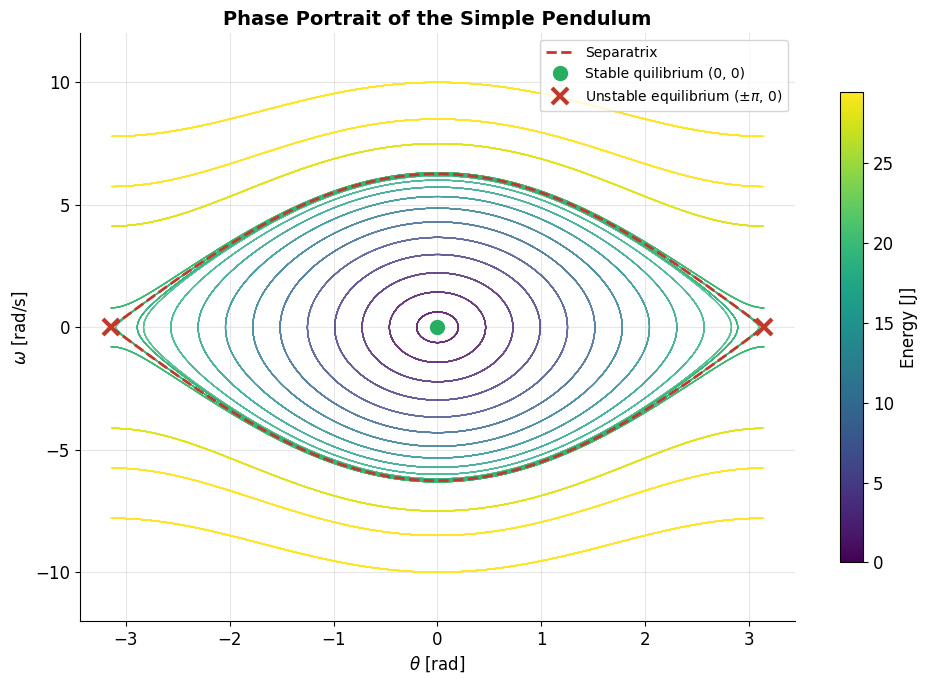

In [6]:
# Phase portrait

fig, ax = plt.subplots(figsize=(10, 7))

dt_phase = 0.01
t_span_phase = (0, 20)

# Energy levels to show (normalized: E / (m*g*L))
# Separatrix energy = 2*m*g*L (when bob is at top, v=0)
E_sep = 2.0 * g * L

# Collect trajectories at various energy levels
# Start from theta=0, vary omega to set energy
initial_conditions = []

# Oscillating trajectories (E < separatrix)
for theta0 in np.linspace(0.2, np.pi - 0.05, 12):
    initial_conditions.append((theta0, 0))

# Whirling trajectories (E > separatrix)
for omega0 in 7.5, 8.5, 10.0:
    initial_conditions.append((0, omega0))
    initial_conditions.append((0, -omega0))

# Near-separatrix trajectories 
omega_sep = np.sqrt(2 * g / L * 2)  # omega at theta=0 on separatrix
for delta in [-0.05, 0.05]:
    initial_conditions.append((0.0, omega_sep + delta))
    initial_conditions.append((0.0, -(omega_sep + delta)))

# Separatrix itself (start near unstable equilibrium)
for eps in [0.001, -0.001]:
    initial_conditions.append((np.pi - eps, eps* 0.1))
    initial_conditions.append((-np.pi + eps, eps* 0.1))

# Colormap based on energy
norm = Normalize(vmin=0, vmax=E_sep * 1.5)
cmap = cm.viridis

for ic in initial_conditions:
    t, x = integrate_rk4(pendulum_deriv, np.array(ic), t_span_phase, dt_phase)
    theta = x[:, 0]
    omega = x[:, 1]
    E = pendulum_energy(theta[0], omega[0])
    color = cmap(norm(E))

    # wrap theta to [-pi, pi] for clean plotting
    theta_wrapped = (theta + np.pi) % (2 * np.pi) - np.pi

    # split at wrapping discountinuities for whirling trajectories
    dtheta = np.abs(np.diff(theta_wrapped))
    split_idx = np.where(dtheta > np.pi)[0]

    if len(split_idx) == 0:
        ax.plot(theta_wrapped, omega, color=color, linewidth=0.8, alpha=0.8)
    else:
        segments = np.split(np.arange(len(theta_wrapped)), split_idx + 1)
        for seg in segments:
            ax.plot(theta_wrapped[seg], omega[seg], color=color, linewidth=0.8, alpha=0.85)

# Draw the separatrix explicitly
theta_sep = np.linspace(-np.pi + 0.001, np.pi - 0.001, 500)
omega_sep_upper = np.sqrt(2 * g / L * (1 + np.cos(theta_sep)))
ax.plot(theta_sep, omega_sep_upper, color=C_RED, linewidth=2.0, linestyle='--', label='Separatrix')
ax.plot(theta_sep, -omega_sep_upper, color=C_RED, linewidth=2.0, linestyle='--')

# Fixed points
ax.plot(0, 0, "o", color=C_GREEN, markersize=10, zorder=5, label="Stable quilibrium (0, 0)")
ax.plot(np.pi, 0, "x", color=C_RED, markersize=12, markeredgewidth=3, zorder=5, label="Unstable equilibrium ($\pm\pi$, 0)")
ax.plot(-np.pi, 0, "x", color=C_RED, markersize=12, markeredgewidth=3, zorder=5)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="Energy [J]", shrink=0.8)

ax.set_xlabel(r"$\theta$ [rad]")
ax.set_ylabel(r"$\omega$ [rad/s]")
ax.set_title("Phase Portrait of the Simple Pendulum", fontweight='bold')
ax.set_xlim(-np.pi - 0.3, np.pi + 0.3)
ax.set_ylim(-12, 12)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

**Reading the phase portrait:**
- Closed loops = oscillation (the pendulum swings back and forth).
- The red dashed separatrix = the trajectory with _exactly_ enough energy to reach the top and stop. 
- It takes **infinite time** to reach $(\pm\pi, 0)$; here's why:
  - At the top, the gravitational torque is zero ($\sin\pi = 0$).
  - As the pendulum approaches, the decelarating force gets weaker and weaker while the velocity also approaches zero. 
  - It's like a ball rolling up a hill that flattens out at the summit - the ball slows down, but the hill keeps getting flatter, so there's less force to slow it but also less velocity to carry it forward. The ball asymptotically creeps toward the top but never arrives in finite time. 
  - Any energy _above_ the separatrix: the pendulum whirls over. Any energy _below_: it swings back. The separatrix is the knife-edge between these two behaviors. 
- Open curves above/below = continuous rotation (the pendulum whirls).
- The green dot at the origin is a **center** (neutrally stable). The red crosses at $\pm\pi$ are **saddle points** (unstable).

---
## 4. Animated Pendulum

Now let's watch it swing. We run at a large amplitude ($\theta_0 = 2.5$ rad $\approx 143^\circ$) so that the nonlinear behavior is clearly visible: the period is longer than the small-angle prediction, and the motion is visible non-sinusoidal. 

In [ ]:
# Animated pendulum: physical view + phase portrait

# Simulate
theta0_anim = 2.5
x0_anim = np.array([theta0_anim, 0])
dt_anim = 0.02
t_anim, x_anim = integrate_rk4(pendulum_deriv, x0_anim, (0, 10), dt_anim)
theta_anim = x_anim[:, 0]
omega_anim = x_anim[:, 1]

# Downsample for smoother animation
skip = 2
theta_anim = theta_anim[::skip]
omega_anim = omega_anim[::skip]
t_anim = t_anim[::skip]
n_frames = len(t_anim)

# Pre-compute bob positions
bob_x = L * np.sin(theta_anim)
bob_y = -L * np.cos(theta_anim)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# Left panel: physical pendulum
ax1.set_xlim(-1.6, 1.6)
ax1.set_ylim(-1.8, 0.5)
ax1.set_aspect('equal')
ax1.set_title('Pendulum', fontweight='bold')
ax1.grid(False)
ax1.axhline(0, color='gray', linewidth=0.5)

# Ceiling
ax1.plot([-0.4, 0.4], [0, 0], color=C_DARK, linewidth=4)
for xh in np.linspace(-0.35, 0.35, 6):
    ax1.plot([xh, xh - 0.1], [0.0, 0.12], color=C_DARK, linewidth=1)

rod_line, = ax1.plot([], [], color=C_DARK, linewidth=2, zorder=3)
bob_dot, = ax1.plot([], [], 'o', color=C_BLUE, markersize=20, zorder=4, markeredgecolor=C_DARK, markeredgewidth=1.5)
trail_line, = ax1.plot([], [], color=C_BLUE, linewidth=0.5, alpha=0.3)
time_text = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, fontsize=11, verticalalignment='top')

# Right panel: phase portrait
ax2.set_xlim(-3.2, 3.2)
ax2.set_ylim(-10, 10)
ax2.set_xlabel(r'$\theta$ [rad]')
ax2.set_ylabel(r'$\omega$ [rad/s]')
ax2.set_title('Phase Space', fontweight='bold')

# Draw separatrix in background
thata_sep = np.linspace(-np.pi + 0.001, np.pi - 0.001, 500)
omega_sep_upper = np.sqrt(2 * g / L * (1 - np.cos(thata_sep)))
ax2.plot(thata_sep, omega_sep_upper, color=C_RED, linewidth=1, linestyle='--', alpha=0.4)
ax2.plot(thata_sep, -omega_sep_upper, color=C_RED, linewidth=1, linestyle='--', alpha=0.4)

phase_trace, = ax2.plot([], [], color=C_BLUE, linewidth=1.5, alpha=0.7)
phase_dot, = ax2.plot([], [], 'o', color=C_ORANGE, markersize=8, zorder=5)

plt.tight_layout()


def init():
    rod_line.set_data([], [])
    bob_dot.set_data([], [])
    trail_line.set_data([], [])
    time_text.set_text('')
    phase_trace.set_data([], [])
    phase_dot.set_data([], [])
    return rod_line, bob_dot, trail_line, time_text, phase_trace, phase_dot


def animate(i):
    # physical pendulum
    rod_line.set_data([0, bob_x[i]], [0, bob_y[i]])
    bob_dot.set_data([bob_x[i]], [bob_y[i]])

    # Trail (last 50 frames)
    trail_start = max(0, i - 50)
    trail_line.set_data(bob_x[trail_start:i+1], bob_y[trail_start:i+1])
    time_text.set_text(f't = {t_anim[i]:.2f}')

    # phase portrait
    phase_trace.set_data(theta_anim[:i+1], omega_anim[:i+1])
    phase_dot.set_data([theta_anim[i]], [omega_anim[i]])

    return rod_line, bob_dot, trail_line, time_text, phase_trace, phase_dot


anim = animation.FuncAnimation(fig, animate, init_func=init, frames=n_frames, interval=30, blit=True)

plt.close(fig)
HTML(anim.to_html5_video())

Notice how the phase portrait traces out a closed orbit - energy is conserved, so the system returns to the same state every period. The orbit is clearly not circular (it would be circular only for small oscillations under the $\sin\theta \approx \theta$ approximation).

> **Experiment:** What initial $\omega$ (starting from $\theta=0$) makes the pendulum _just barely_ go over the top? Hint: think about the separatrix energy.

---
## 5. Damped Pendulum

Real pendulum lose energy to friction. We add a linear damping:

$$\ddot{\theta} = -\frac{g}{L}\sin\theta - b\,\omega$$

where $b > 0$ is the damping coefficient. The phase portrait should spiral inward to the origin - the pendulum rings down.

In [ ]:
# Damped pendulum phase portrait

b_damp = 0.3
skip = 2

def pendulum_deriv_damped(t, state):
    return pendulum_deriv(t, state, b=b_damp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Undamped phase portrait for reference
for theta0 in np.linspace(0.3, 2.8, 8):
    t, x = integrate_rk4(pendulum_deriv, np.array([theta0, 0.0]), (0, 15), 0.01)
    ax1.plot(x[:, 0], x[:, 1], color=C_BLUE, linewidth=0.7, alpha=0.5)
ax1.set_xlabel(r'$\theta$ [rad]')
ax1.set_ylabel(r'$\omega$ [rad/s]')
ax1.set_title('Undamped (b = 0)', fontweight='bold')
ax1.set_xlim(-3.5, 3.5)
ax1.set_ylim(-8, 8)
ax1.plot(0, 0, 'o', color=C_GREEN, markersize=8, zorder=5)

# Damped phase portrait
for theta0 in np.linspace(0.3, 2.8, 8):
    t, x = integrate_rk4(pendulum_deriv_damped, np.array([theta0, 0.0]), (0, 30), 0.01)
    ax2.plot(x[:, 0], x[:, 1], color=C_PURPLE, linewidth=0.7, alpha=0.7)
# Also from negative initial angles
for theta0 in np.linspace(-2.8, -0.3, 5):
    t, x = integrate_rk4(pendulum_deriv_damped, np.array([theta0, 0.0]), (0, 30), 0.01)
    ax2.plot(x[:, 0], x[:, 1], color=C_PURPLE, linewidth=0.7, alpha=0.7)
ax2.set_xlabel(r'$\theta$ [rad]')
ax2.set_ylabel(r'$\omega$ [rad/s]')
ax2.set_title(f'Damped (b = {b_damp})', fontweight='bold')
ax2.set_xlim(-3.5, 3.5)
ax2.set_ylim(-8, 8)
ax2.plot(0, 0, 'o', color=C_GREEN, markersize=8, zorder=5, label='Stable spiral')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [23]:
# Animated damped pendulum

theta0_damp = 2.5
x0_damp = np.array([theta0_damp, 0.0])
dt_damp = 0.02
t_damp, x_damp = integrate_rk4(pendulum_deriv_damped, x0_damp, (0, 15), dt_damp)
theta_d = x_damp[::skip, 0]
omega_d = x_damp[::skip, 1]
t_d = t_damp[::skip]
n_frames_d = len(theta_d)

bob_xd = L * np.sin(theta_d)
bob_yd = -L * np.cos(theta_d)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# Left: physical pendulum
ax1.set_xlim(-1.6, 1.6)
ax1.set_ylim(-1.8, 0.5)
ax1.set_aspect('equal')
ax1.set_title(f'Damped Pendulum (b = {b_damp})', fontweight='bold')
ax1.grid(False)
ax1.axhline(y=0, color='gray', linewidth=0.5)
ax1.plot([-0.4, 0.4], [0, 0], color=C_DARK, linewidth=4)
for xh in np.linspace(-0.35, 0.35, 6):
    ax1.plot([xh, xh - 0.1], [0.0, 0.12], color=C_DARK, linewidth=1)

rod_d, = ax1.plot([], [], color=C_DARK, linewidth=2.5, zorder=3)
bob_d, = ax1.plot([], [], 'o', color=C_PURPLE, markersize=20, zorder=4, markeredgecolor=C_DARK, markeredgewidth=1.5)
trail_d, = ax1.plot([], [], color=C_PURPLE, linewidth=0.5, alpha=0.3)
time_d = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, fontsize=11, verticalalignment='top')

# Right: phase portriat with spiral
ax2.set_xlim(-3.0, 3.0)
ax2.set_ylim(-8, 8)
ax2.set_xlabel(r'$\theta$ [rad]')
ax2.set_ylabel(r'$\omega$ [rad/s]')
ax2.set_title('Phase Portrait', fontweight='bold')
ax2.plot(0, 0, 'o', color=C_GREEN, markersize=8, zorder=5)

phase_trace_d, = ax2.plot([], [], color=C_PURPLE, linewidth=1.5, alpha=0.7)
phase_dot_d, = ax2.plot([], [], 'o', color=C_ORANGE, markersize=8, zorder=5)

plt.tight_layout()

def init_d():
    rod_d.set_data([], [])
    bob_d.set_data([], [])
    trail_d.set_data([], [])
    time_d.set_text('')
    phase_trace_d.set_data([], [])
    phase_dot_d.set_data([], [])
    return rod_d, bob_d, trail_d, phase_trace_d, phase_dot_d, time_d

def animate_d(i):
    rod_d.set_data([0, bob_xd[i]], [0, bob_yd[i]])
    bob_d.set_data([bob_xd[i]], [bob_yd[i]])
    trail_start = max(0, i - 80)
    trail_d.set_data(bob_xd[trail_start:i+1], bob_yd[trail_start:i+1])
    time_d.set_text(f't = {t_d[i]:.1f} s')
    phase_trace_d.set_data(theta_d[:i+1], omega_d[:i+1])
    phase_dot_d.set_data([theta_d[i]], [omega_d[i]])
    return rod_d, bob_d, trail_d, phase_trace_d, phase_dot_d, time_d

anim_d = animation.FuncAnimation(fig, animate_d, frames=n_frames_d, init_func=init_d, interval=30, blit=True)

plt.close(fig)
HTML(anim_d.to_html5_video())

The spiral in phase space is the signature of a **stable spiral point** (or stable focus). Every initial condition spirals into the origin. The undamped center gas become a sink.

> **Experiment:** Increase the damping coefficient `b`. At what value does the pendulum stop oscillating and just slide monotonically to the bottom? (That's the **overdamped** regime.)

---
## 6. Double Pendulum: Chaos

Now the payoff. Attach a second pendulum to the end of the first. The system has 4 degrees of freedom: $[\theta_1, \omega_1, \theta_2, \omega_2]$. 

The equations of motion come from the Lagrangian. They are messy, so we just give the final result:

$$\ddot{\theta_1} = \frac{-g(2m_1+m_2)\sin\theta_1 - m_2 g\sin(\theta_1-2\theta_2) - 2\sin(\theta_1-\theta_2)\,m_2\left(\dot{\theta}_2^2 L_2 + \dot{\theta}_1^2 L_1\cos(\theta_1-\theta_2)\right)}{L_1\left(2m_1+m_2-m_2\cos(2\theta_1-2\theta_2)\right)}$$

$$\ddot{\theta_2} = \frac{2\sin(\theta_1-\theta_2)\left(\dot{\theta}_1^2 L_1(m_1+m_2) + g(m_1+m_2)\cos\theta_1 + \dot{\theta}_2^2 L_2 m_2\cos(\theta_1-\theta_2)\right)}{L_2\left(2m_1+m_2-m_2\cos(2\theta_1-2\theta_2)\right)}$$

The key property: **sensitive dependence on initial conditions** (chaos). Two double pendulums started with a tiny difference will diverge exponentially. 

In [51]:
# Double pendulum dynamics

def double_pendulum_deriv(t, state, m1=1.0, m2=1.0, L1=1.0, L2=1.0, g=9.81):
    """Equations of motion of the double pendulum"""
    th1, w1, th2, w2 = state
    delta = th1 - th2

    denom1 = L1 * (2*m1 + m2 - m2 * np.cos(2*delta))
    denom2 = L2 * (2*m1 + m2 - m2 * np.cos(2*delta))

    alpha1 = (
        -g*(2*m1 + m2) * np.sin(th1)
        - m2*g*np.sin(th1 - 2*th2)
        - 2*np.sin(delta)*m2*(w2**2*L2 + w1**2*L1*np.cos(delta))
    ) / denom1

    alpha2 = (
        2*np.sin(delta) *
        (w1**2*L1*(m1+m2) + g*(m1+m2)*np.cos(th1) +
        w2**2*L2*m2*np.cos(delta))
    ) / denom2

    return [w1, alpha1, w2, alpha2]


def double_pendulum_positions(state, L1=1.0, L2=1.0):
    """Compute x1, y1, x2, y2 from state."""
    th1, _, th2, _ = state
    x1 = L1 * np.sin(th1)
    y1 = -L1 * np.cos(th1)
    x2 = x1 + L2 * np.sin(th2)
    y2 = y1 - L2 * np.cos(th2)
    return x1, y1, x2, y2


print("Double pendulum dynamics defined.")

Double pendulum dynamics defined.


In [52]:
# Simulate two double pendulums with slightly different initial conditions

ic_A = [np.pi/2, 0, np.pi/2, 0]             # pendulum A
ic_B = [np.pi/2 + 0.001, 0, np.pi/2, 0]     # pendulum B: differ by 0.001 in the first angle

t_end = 60.0
t_eval = np.arange(0, t_end, 0.01)

sol_A = solve_ivp(double_pendulum_deriv, (0, t_end), ic_A, t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
sol_B = solve_ivp(double_pendulum_deriv, (0, t_end), ic_B, t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)

print(f"Simulated {t_end}s with {len(t_eval)} timesteps.")
print(f"Initial difference: {abs(ic_B[0] - ic_A[0]):.4f} rad")

Simulated 60.0s with 6000 timesteps.
Initial difference: 0.0010 rad


We measure how fast the two trajectories diverge. The state difference at time $t$ is:

$$\Delta(t) = \sqrt{(\theta_1^A(t) - \theta_1^B(t))^2 + (\theta_2^A(t) - \theta_2^B(t))^2}$$

For a chaotic system, this grows exponentially: $\Delta(t) \sim \Delta_0 \, e^{\lambda t}$, where $\lambda$ is the **Lyapunov exponent**. A positive $\lambda$ means chaos, i.e. nearby trajectories separate exponentially. We estimate $\lambda$ by fitting a line to $\ln \Delta(t)$ during the early growth phase (before the divergence saturates).

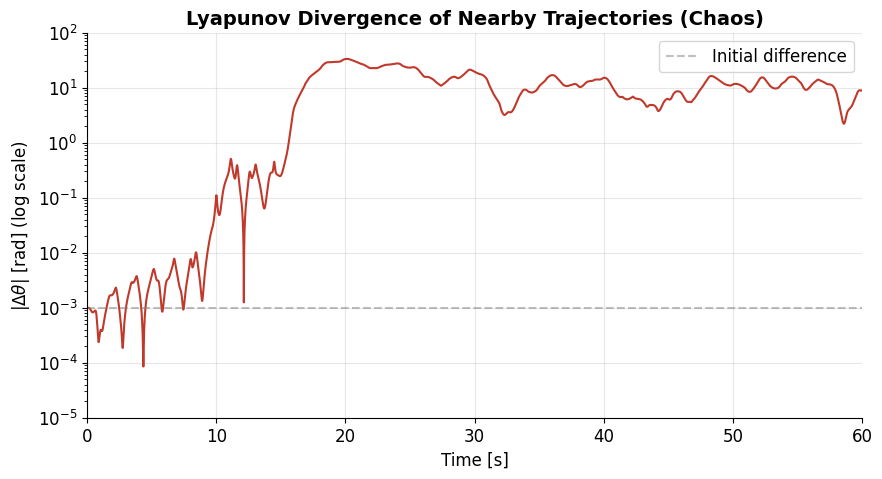

Estimated Lyapunov exponent: 0.35 /s
(Positive = chaos. Doubling time ~ 2.00 s)


In [53]:
# Lyapunov divergence plot

diff_th1 = np.abs(sol_B.y[0] - sol_A.y[0])
diff_th2 = np.abs(sol_B.y[2] - sol_A.y[2])
diff_total = np.sqrt(diff_th1**2 + diff_th2**2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(sol_A.t, diff_total, color=C_RED, linewidth=1.5)
ax.axhline(0.001, color='gray', linestyle='--', alpha=0.5, label='Initial difference')
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$|\Delta\theta|$ [rad] (log scale)')
ax.set_title('Lyapunov Divergence of Nearby Trajectories (Chaos)', fontweight='bold')
ax.legend()
ax.set_ylim(1e-5, 100)
ax.set_xlim(0, t_end)
plt.show()

# Estimate Lyapunov exponent from early exponential growth
# Find region where difference is still small but growing
mask = (diff_total < 0.1) & (diff_total > 1e-4)
if np.sum(mask) > 10:
    t_fit = sol_A.t[mask]
    d_fit = diff_total[mask]
    coeffs = np.polyfit(t_fit, np.log(d_fit), 1)
    lyap = coeffs[0]
    print(f"Estimated Lyapunov exponent: {lyap:.2f} /s")
    print(f"(Positive = chaos. Doubling time ~ {np.log(2)/lyap:.2f} s)")

In [54]:
# Animated double pendulum

# Downsample for animation
anim_skip = 3
t_dp = sol_A.t[::anim_skip]
states_A = sol_A.y[:, ::anim_skip].T
states_B = sol_B.y[:, ::anim_skip].T
n_dp = len(t_dp)

# Precompute positions
pos_A = np.array([double_pendulum_positions(state) for state in states_A])
pos_B = np.array([double_pendulum_positions(state) for state in states_B])

fig, (ax1, ax2)  = plt.subplots(1, 2, figsize=(13, 6))

# Left: pendulum A
for ax, title, color in [(ax1, "Pendulum A", C_BLUE), (ax2, "Pendulum B", C_ORANGE)]:
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 1.0)
    ax.set_aspect('equal')
    ax.set_title(title, fontweight='bold', color=color)
    ax.grid(False)
    ax.plot([-0.3, 0.3], [0.0, 0.0], color=C_DARK, linewidth=4)

# Artists for A
rod1_A, = ax1.plot([], [], color=C_DARK, linewidth=2.5, zorder=3)
rod2_A, = ax1.plot([], [], color=C_DARK, linewidth=2.5, zorder=3)
bob1_A, = ax1.plot([], [], 'o', color=C_BLUE, markersize=14, zorder=4, markeredgecolor=C_DARK, markeredgewidth=1.2)
bob2_A, = ax1.plot([], [], 'o', color=C_BLUE, markersize=14, zorder=4, markeredgecolor=C_DARK, markeredgewidth=1.2)
trace_A, = ax1.plot([], [], color=C_BLUE, linewidth=0.5, alpha=0.4)
time_dp = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, fontsize=11, verticalalignment='top')

# Artists for B
rod1_B, = ax2.plot([], [], color=C_DARK, linewidth=2.5, zorder=3)
rod2_B, = ax2.plot([], [], color=C_DARK, linewidth=2.5, zorder=3)
bob1_B, = ax2.plot([], [], 'o', color=C_ORANGE, markersize=14, zorder=4, markeredgecolor=C_DARK, markeredgewidth=1.2)
bob2_B, = ax2.plot([], [], 'o', color=C_ORANGE, markersize=14, zorder=4, markeredgecolor=C_DARK, markeredgewidth=1.2)
trace_B, = ax2.plot([], [], color=C_ORANGE, linewidth=0.5, alpha=0.4)
time_dp = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, fontsize=11, verticalalignment='top')

plt.tight_layout()

def init_dp():
    for artist in [rod1_A, rod2_A, bob1_A, bob2_A, trace_A, rod1_B, rod2_B, bob1_B, bob2_B, trace_B]:
        artist.set_data([], [])
    time_dp.set_text('')
    return (rod1_A, rod2_A, bob1_A, bob2_A, trace_A, rod1_B, rod2_B, bob1_B, bob2_B, trace_B, time_dp)

def animate_dp(i):
    x1a, y1a, x2a, y2a = pos_A[i]
    x1b, y1b, x2b, y2b = pos_B[i]

    # pendulum A
    rod1_A.set_data([0, x1a], [0, y1a])
    rod2_A.set_data([x1a, x2a], [y1a, y2a])
    bob1_A.set_data([x1a], [y1a])
    bob2_A.set_data([x2a], [y2a])
    trail_start = max(0, i - 100)
    trace_A.set_data(pos_A[trail_start:i+1, 2], pos_A[trail_start:i+1, 3])

    # pendulum B
    rod1_B.set_data([0, x1b], [0, y1b])
    rod2_B.set_data([x1b, x2b], [y1b, y2b])
    bob1_B.set_data([x1b], [y1b])
    bob2_B.set_data([x2b], [y2b])
    trail_start = max(0, i - 100)
    trace_B.set_data(pos_B[trail_start:i+1, 2], pos_B[trail_start:i+1, 3])

    time_dp.set_text(f't = {t_dp[i]:.2f}')
    return (rod1_A, rod2_A, bob1_A, bob2_A, trace_A, rod1_B, rod2_B, bob1_B, bob2_B, trace_B, time_dp)

anim_dp = animation.FuncAnimation(fig, animate_dp, init_func=init_dp, frames=n_dp, interval=30, blit=True)

plt.close(fig)
HTML(anim_dp.to_html5_video())

The two pendulums start visually identical and then diverge wildly. This is **deterministic chaos**: the equations are completely deterministic, but any finite measurement error gets amplified exponentially. The Lyapunov exponent quantifies this rate. 

This is the fundamental challenge of simulation: for chaotic systems, long-term prediction is impossible regardless of numerical precision. What we _can_ do is predict **statistical** properties (energy distribution, frequency spectra, Lyapunov exponents). 

### The Three-Body Problem Connection

The double pendulum's chaos is the same phenomenon behind the famous **three-body problem** in celestial mechanics. Both are fully deterministic - Newton's laws give you exact ODEs - and both exhibit exponential sensitivity to initial conditions. The chaos doesn't come from randomness; it comes from **nonlinear coupling** between degrees of freedom. 

In the double pendulum, the two links exchange energy through the Lagrangian coupling terms. In the three-body problem, any two bodies interact gravitationally, but the third body perturbs that interaction, and the perturbation feeds back. The feedback creates the exponential divergence. 

The deeper structual reason both are chaotic is **non-integrability**: neither system has enough conserved quantities to constrain its trajectories. A two-body gravitational system has enough conserved quantities (energy, angular momentum, the Laplace-Runge-Lenz vector) to solve completely - that's why Kepler orbits are clean ellipses. Adding a third body breaks most of the conservation laws. Similarly, a single pendulum conserves energy and lives on a 1D curve in phase space. The double pendulum's 4D phase space has only one conserved quantity (total energy), leaving 3 dimensions of freedom - more than enough room for chaos. 

The recipe: **deterministic equations + nonlinear coupling + insufficient conserved quantities = chaos**.

---
## 7. Fixed-Point Classification

Everything we've seen in the phase portraits maps to a vocabulary from linear stability analysis. At each equilibrium, you linearize the dynamics ($\dot{\mathbf{x}} = A\mathbf{x}$) and look at the eigenvalues of $A$ — the same analysis done in Phase 1.75 of the Icarus project.

| Equilibrium | Eigenvalues of $A$ | Name | Phase portrait signature |
|---|---|---|---|
| $(\theta, \omega) = (0, 0)$, undamped | $\pm i\omega_n$ (purely imaginary) | **Center** | Closed orbits — neutral stability |
| $(\theta, \omega) = (0, 0)$, damped | $\alpha \pm i\omega_d$, $\alpha < 0$ (negative real part) | **Stable spiral** | Trajectories spiral inward |
| $(\theta, \omega) = (0, 0)$, overdamped | $\lambda_1, \lambda_2 < 0$ (both real, negative) | **Stable node** | Trajectories slide monotonically to origin |
| $(\theta, \omega) = (\pm\pi, 0)$ | one positive, one negative real | **Saddle point** | Unstable — separatrix passes through it |

The pendulum at the bottom ($\theta = 0$) has $A = \begin{bmatrix} 0 & 1 \\ -g/L & -b \end{bmatrix}$, with eigenvalues $\lambda = \frac{-b \pm \sqrt{b^2 - 4g/L}}{2}$.

- $b = 0$: pure imaginary eigenvalues → center.
- $0 < b < 2\sqrt{g/L}$: complex with negative real part → stable spiral (what we saw).
- $b \geq 2\sqrt{g/L}$: both real and negative → stable node (overdamped, no oscillation).

The unstable equilibrium at $\theta = \pm\pi$ has one positive and one negative eigenvalue regardless of $b$ — it is always a saddle, and the separatrix is its stable and unstable manifolds.

**Why this matters for 6-DOF**: every equilibrium in a higher-dimensional system — a hovering rocket, a trimmed attitude — is characterized by the same eigenvalue classification. The steps are identical: linearize, compute eigenvalues, read off the stability type. The pendulum is the simplest possible case to build that intuition.

---
## Summary

| Concept | What we built | Key takeaway |
|---------|---------------|--------------|
| State vector | $[\theta, \omega]$ | Every simulation starts here |
| Euler vs RK4 | Two integrators | Euler drifts; RK4 conserves energy |
| Phase portrait | Global view of dynamics | Fixed points, separatrices, stability |
| Damping | Spiral to equilibrium | Dissipation turns centers into spirals |
| Double pendulum | Chaos | Sensitive dependence on initial conditions |
| Fixed-point types | Eigenvalue classification | Center, stable spiral, stable node, saddle |

**Next notebook:** We move from 1D rotation to 2D with a rotating rigid bar — introducing the moment of inertia tensor, body-fixed vs. inertial frames, and the direct precursor to 3D attitude dynamics.